In [1]:
pip install tensorflowjs

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Importing Libraries
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import load_img, ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten


In [3]:
%pip install tensorflow


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

In [5]:
# data_dir='/content/drive/MyDrive/butterflyml/Butterfly/butterfly_photos/'
# print(data_dir)
data_dir='C:/Users/jerwin/Documents/GitHub/butterfly_photos/Larvae Species/Larvae-Common Lime/'
print(data_dir)

C:/Users/jerwin/Documents/GitHub/butterfly_photos/Larvae Species/Larvae-Common Lime/


In [6]:
data_dir=tf.keras.preprocessing.image_dataset_from_directory(data_dir)

Found 3737 files belonging to 14 classes.


In [7]:
count = 0
dirs = os.listdir('C:/Users/jerwin/Documents/GitHub/butterfly_photos/Larvae Species/Larvae-Common Lime/')
for dir in dirs:
    files = list(os.listdir('C:/Users/jerwin/Documents/GitHub/butterfly_photos/Larvae Species/Larvae-Common Lime/'+dir))
    print( dir +' Folder has '+ str(len(files)) + ' C:/Users/jerwin/Documents/GitHub/butterfly_photos/Larvae Species/Larvae-Common Lime/')
    count = count + len(files)
print( 'Images Folder has '+ str(count) + 'C:/Users/jerwin/Documents/GitHub/butterfly_photos/Larvae Species/Larvae-Common Lime/')

day 01 Folder has 143 C:/Users/jerwin/Documents/GitHub/butterfly_photos/Larvae Species/Larvae-Common Lime/
day 02-first instar Folder has 671 C:/Users/jerwin/Documents/GitHub/butterfly_photos/Larvae Species/Larvae-Common Lime/
day 03 Folder has 212 C:/Users/jerwin/Documents/GitHub/butterfly_photos/Larvae Species/Larvae-Common Lime/
day 04-second instar Folder has 270 C:/Users/jerwin/Documents/GitHub/butterfly_photos/Larvae Species/Larvae-Common Lime/
day 05 Folder has 201 C:/Users/jerwin/Documents/GitHub/butterfly_photos/Larvae Species/Larvae-Common Lime/
day 06-third instar Folder has 113 C:/Users/jerwin/Documents/GitHub/butterfly_photos/Larvae Species/Larvae-Common Lime/
day 07 Folder has 53 C:/Users/jerwin/Documents/GitHub/butterfly_photos/Larvae Species/Larvae-Common Lime/
day 08-fourth instar Folder has 363 C:/Users/jerwin/Documents/GitHub/butterfly_photos/Larvae Species/Larvae-Common Lime/
day 09 Folder has 229 C:/Users/jerwin/Documents/GitHub/butterfly_photos/Larvae Species/Larv

In [8]:
base_dir = 'C:/Users/jerwin/Documents/GitHub/butterfly_photos/Larvae Species/Larvae-Common Lime/'
img_size = 180
batch = 32

In [9]:
train_ds = tf.keras.utils.image_dataset_from_directory( base_dir,
                                                       seed = 123,
                                                       validation_split=0.2,
                                                       subset = 'training',
                                                       batch_size=batch,
                                                       image_size=(img_size,img_size))

val_ds = tf.keras.utils.image_dataset_from_directory( base_dir,
                                                       seed = 123,
                                                       validation_split=0.2,
                                                       subset = 'validation',
                                                       batch_size=batch,
                                                       image_size=(img_size,img_size))

Found 3737 files belonging to 14 classes.
Using 2990 files for training.
Found 3737 files belonging to 14 classes.
Using 747 files for validation.


In [10]:
larval_stages_names = train_ds.class_names
larval_stages_names

['day 01',
 'day 02-first instar',
 'day 03',
 'day 04-second instar',
 'day 05',
 'day 06-third instar',
 'day 07',
 'day 08-fourth instar',
 'day 09',
 'day 10-fifth instar',
 'day 11',
 'day 12',
 'day 13',
 'day 14']

In [11]:
import matplotlib.pyplot as plt

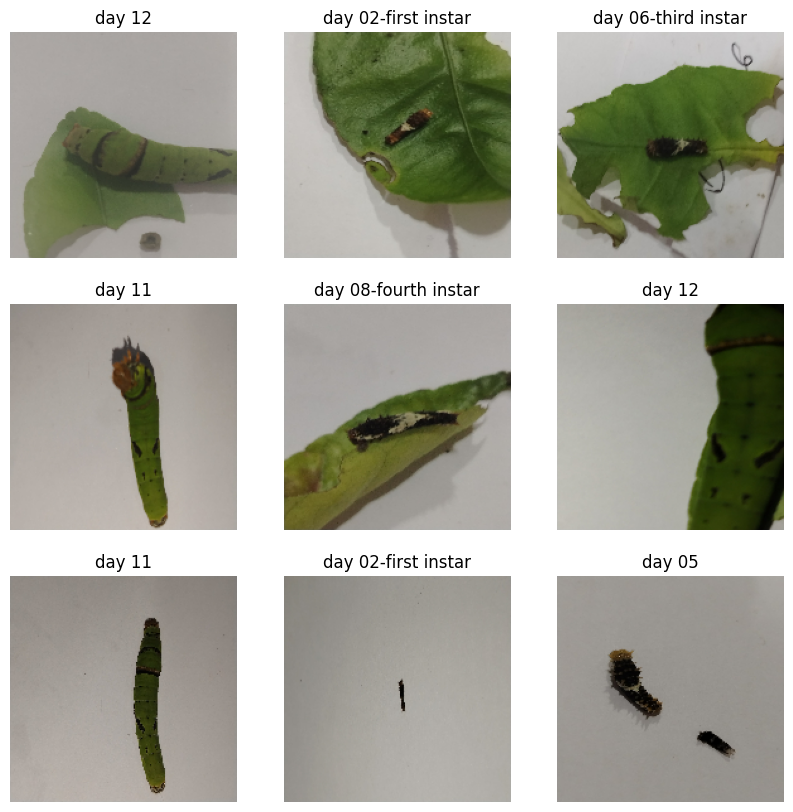

In [12]:
i = 0
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3, i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(larval_stages_names[labels[i]])
        plt.axis('off')

In [13]:
#index number and butterfly_species_names
# fig, ax = plt.subplots(ncols=4, figsize=(20, 20))
# for idx, img in enumerate(batch[0][:4]):
#     ax[idx].imshow(img.astype(int))
#     label_with_number = f"{batch[1][idx]} - {butterfly_species_names[batch[1][idx]]}"  # Concatenate number and label
#     ax[idx].title.set_text(label_with_number)  # Set title with both


In [14]:
AUTOTUNE = tf.data.AUTOTUNE

In [15]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = AUTOTUNE)

In [16]:
val_ds = val_ds.cache().prefetch(buffer_size = AUTOTUNE)

##Data Augmentation

In [17]:
# data_augmentation = Sequential([
#     layers.RandomFlip("horizontal", input_shape = (img_size,img_size,3)),
#     layers.RandomRotation(0.1),
#     layers.RandomZoom(0.1)
# ])
from tensorflow.keras.layers import Input, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.models import Model
inputs = Input(shape=(img_size, img_size, 3))
x = RandomFlip("horizontal")(inputs)
x = RandomRotation(0.1)(x)
x = RandomZoom(0.1)(x)
data_augmentation = Model(inputs, x)

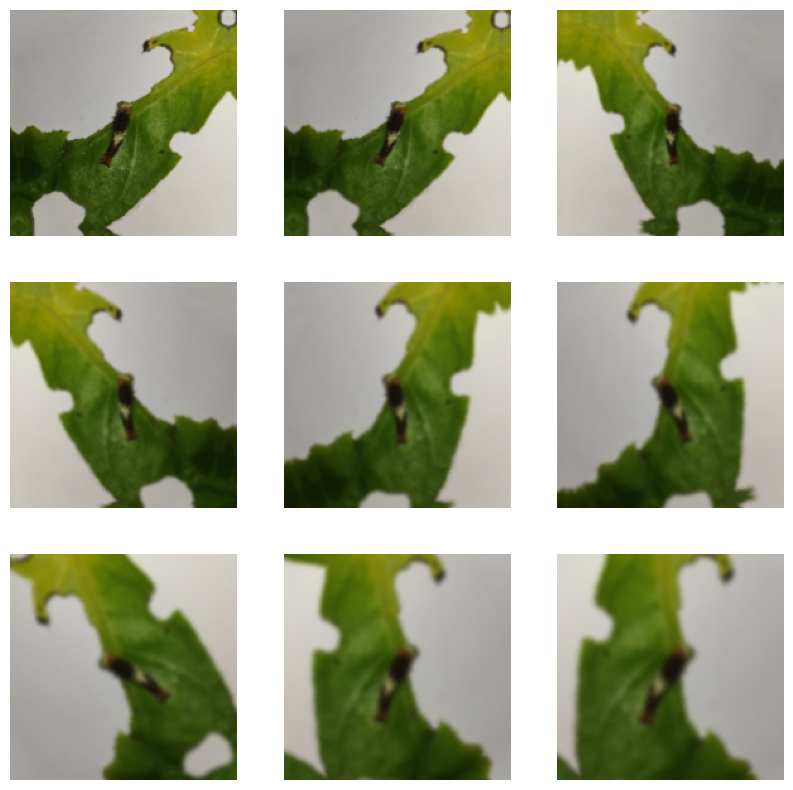

In [18]:
i = 0
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        images = data_augmentation(images)
        plt.subplot(3,3, i+1)
        plt.imshow(images[0].numpy().astype('uint8'))
        plt.axis('off')

##Model Creation

In [19]:
model = Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    Conv2D(16, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Dropout(0.2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(14)
])

In [20]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional (Functional)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,990,446 (15.22 MB)

 Trainable params: 3,990,446 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(train_ds, epochs=15, validation_data=val_ds)

Epoch 1/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 45s 454ms/step - accuracy: 0.2893 - loss: 2.1797 - val_accuracy: 0.4485 - val_loss: 1.6254
Epoch 2/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 219ms/step - accuracy: 0.6161 - loss: 1.2301 - val_accuracy: 0.6894 - val_loss: 1.0609
Epoch 3/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 204ms/step - accuracy: 0.7508 - loss: 0.8116 - val_accuracy: 0.7149 - val_loss: 0.9230
Epoch 4/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 23s 246ms/step - accuracy: 0.8107 - loss: 0.6422 - val_accuracy: 0.7376 - val_loss: 0.8276
Epoch 5/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 34s 360ms/step - accuracy: 0.8656 - loss: 0.4711 - val_accuracy: 0.7992 - val_loss: 0.6627
Epoch 6/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 32s 336ms/step - accuracy: 0.8763 - loss: 0.4208 - val_accuracy: 0.8394 - val_loss: 0.5094
Epoch 7/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 29s 307ms/step - accuracy: 0.8936 - loss: 0.3579 - val_accuracy: 0.8608 - val_loss: 0.5320
Epoch 8/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.9094 - loss: 0.3047 - val_accura

In [23]:
def classify_images(image_path):
    input_image = tf.keras.utils.load_img(image_path, target_size=(180,180))
    input_image_array = tf.keras.utils.img_to_array(input_image)
    input_image_exp_dim = tf.expand_dims(input_image_array,0)

    predictions = model.predict(input_image_exp_dim)
    result = tf.nn.softmax(predictions[0])
    outcome = 'The Image belongs to ' + larval_stages_names[np.argmax(result)] + ' with a score of '+ str(np.max(result)*100)
    return outcome

In [24]:
classify_images('C:/Users/jerwin/Documents/GitHub/butterfly_photos/Larvae Species/Larvae-Common Lime/day 04-second instar/IMG_20250912_153430.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


'The Image belongs to day 04-second instar with a score of 99.91047'

In [25]:
model.save('C:/Users/jerwin/Documents/CNN/CNN Data Augmentation/prettylep/model/model_Larval_Stages.keras')

In [26]:
model.save('C:/Users/jerwin/Documents/CNN/CNN Data Augmentation/prettylep/model/model_Larval_Stages.h5')

In [27]:
# Check the loaded model summary
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional (Functional)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,971,340 (45.67 MB)

 Trainable params: 3,990,446 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,980,894 (30.44 MB)

In [28]:
# Save the model architecture to a JSON file
model_json = model.to_json()
with open("C:/Users/jerwin/Documents/CNN/CNN Data Augmentation/prettylep/json/model_Larval_Stages.json", "w") as json_file:
    json_file.write(model_json)


In [29]:
from tensorflow.keras.models import load_model


In [30]:
model = load_model('C:/Users/jerwin/Documents/GitHub/PrettyLep/model/model_Larval_Stages.h5')

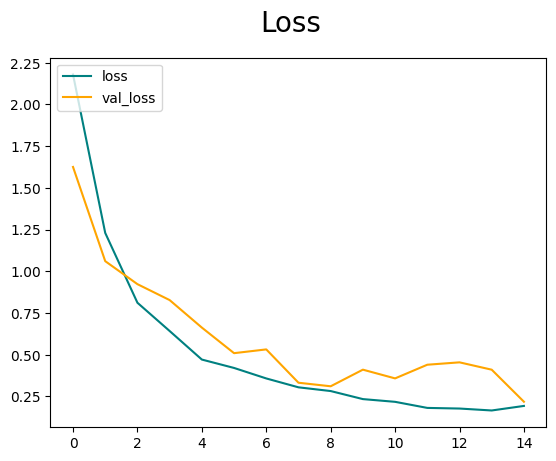

In [31]:
fig = plt.figure()
plt.plot(history.history['loss'], color='teal', label='loss')
plt.plot(history.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

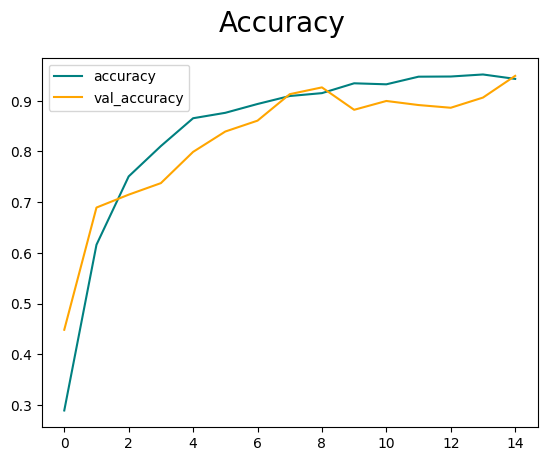

In [32]:
fig = plt.figure()
plt.plot(history.history['accuracy'], color='teal', label='accuracy')
plt.plot(history.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [33]:
# ...existing code...

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

# Evaluate model and plot confusion matrix + F1 score
y_true = []
y_pred = []

for images, labels in val_ds.unbatch():
    img_array = tf.expand_dims(images, 0)  # Add batch dimension
    preds = model.predict(img_array, verbose=0)
    pred_label = np.argmax(preds, axis=1)[0]
    y_true.append(labels.numpy())
    y_pred.append(pred_label)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=larval_stages_names)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=90)
plt.title("Confusion Matrix")
plt.show()

# F1 Score (macro and weighted)
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')
print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")
# ...existing code...

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Assuming y_true and y_pred are your true and predicted labels
# Replace these with your actual label arrays
y_true = ['day 01', 'day 02-first instar', 'day 03', 'day 04-second instar',
    'day 05', 'day 06-third instar', 'day 07', 'day 08',
    'day 09-fourth instar', 'day 10-fifth instar', 'day 11', 'day 12',
    'day 13', 'day 14-sixth instar']  # e.g., ['day 01', 'day 02-first instar', ...]
y_pred = ['day 01', 'day 02-first instar', 'day 03', 'day 04-second instar',
    'day 05', 'day 06-third instar', 'day 07', 'day 08',
    'day 09-fourth instar', 'day 10-fifth instar', 'day 11', 'day 12',
    'day 13', 'day 14-sixth instar']

# Generate report
# report = classification_report(y_true, y_pred, target_names=[
    
# ])
report = classification_report(y_true, y_pred)
print(report)